<a href="https://colab.research.google.com/github/ashishraj-hub/Data-Science-Bootcamp-Project/blob/main/Devtown_Bootcamp_Data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Titanic Dataset.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
df.tail()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,NaN,NaN,NaN


In [4]:
df.shape

(1309, 14)

In [5]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


In [6]:
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipykernel_13975/1654433547.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [7]:
df['body'].fillna(df['body'].mean(), inplace=True)

/tmp/ipykernel_13975/718250601.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['body'].fillna(df['body'].mean(), inplace=True)


In [8]:
# Let's check the current status of missing values
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


From the updated `isnull().sum()` (which will be displayed above), we'll see that `fare`, `cabin`, `embarked`, `boat`, and `home.dest` still have missing values.

### Handling `fare` (Numeric, but had `mode()` issue)

Let's correct how `fare` was filled. Using `mode()` directly with `inplace=True` can be problematic as `mode()` can return multiple values if there's a tie, or a Series object. It's safer to explicitly select the first mode.


In [9]:
# Correctly fill missing 'fare' values with the mode
df['fare'] = df['fare'].fillna(df['fare'].mode()[0])

print(f"Missing values in 'fare' after filling: {df['fare'].isnull().sum()}")

Missing values in 'fare' after filling: 0


### Handling `embarked` (Categorical, Object type)

The 'embarked' column is categorical (object dtype) and has a few missing values. A common strategy for categorical data is to fill missing values with the most frequent category (the mode).


In [10]:
# Get the mode of the 'embarked' column
embarked_mode = df['embarked'].mode()[0]

# Fill missing values in 'embarked' with the mode
df['embarked'] = df['embarked'].fillna(embarked_mode)

print(f"Missing values in 'embarked' after filling: {df['embarked'].isnull().sum()}")
print("\nValue counts for 'embarked' after filling:")
print(df['embarked'].value_counts())

Missing values in 'embarked' after filling: 0

Value counts for 'embarked' after filling:
embarked
S    916
C    270
Q    123
Name: count, dtype: int64


### Handling `cabin`, `boat`, and `home.dest` (Textual/Categorical, Object type with many missing values)

Columns like `cabin`, `boat`, and `home.dest` are object types and have a large number of missing values. For these, it's often appropriate to fill them with a placeholder like 'Unknown' or 'Missing' if you plan to keep them, or consider dropping them if they don't provide significant information due to high missingness.


In [11]:
# Fill missing 'cabin' values with 'Unknown'
df['cabin'] = df['cabin'].fillna('Unknown')
print(f"Missing values in 'cabin' after filling: {df['cabin'].isnull().sum()}")

# Fill missing 'boat' values with 'Missing Boat Info'
df['boat'] = df['boat'].fillna('Missing Boat Info')
print(f"Missing values in 'boat' after filling: {df['boat'].isnull().sum()}")

# Fill missing 'home.dest' values with 'Unknown Destination'
df['home.dest'] = df['home.dest'].fillna('Unknown Destination')
print(f"Missing values in 'home.dest' after filling: {df['home.dest'].isnull().sum()}")

# Let's check all nulls again to confirm all are handled
print("\nMissing values across all columns after these operations:")
df.isnull().sum()

Missing values in 'cabin' after filling: 0
Missing values in 'boat' after filling: 0
Missing values in 'home.dest' after filling: 0

Missing values across all columns after these operations:


,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
cabin,0


In [12]:
print(df[df['age']>30])

      pclass  survived                                             name  \
5          1         1                              Anderson, Mr. Harry   
6          1         1                Andrews, Miss. Kornelia Theodosia   
7          1         0                           Andrews, Mr. Thomas Jr   
8          1         1    Appleton, Mrs. Edward Dale (Charlotte Lamson)   
9          1         0                          Artagaveytia, Mr. Ramon   
...      ...       ...                                              ...   
1286       3         1  Whabee, Mrs. George Joseph (Shawneene Abi-Saab)   
1287       3         0                 Widegren, Mr. Carl/Charles Peter   
1290       3         1                 Wilkes, Mrs. James (Ellen Needs)   
1298       3         0                        Wittevrongel, Mr. Camille   
1301       3         0                             Youseff, Mr. Gerious   

         sex   age  sibsp  parch    ticket     fare    cabin embarked  \
5       male  48.0      0 

In [13]:
print(df.groupby('sex')['survived'].mean())

sex
female    0.727468
male      0.190985
Name: survived, dtype: float64


In [14]:
df_sorted=df.sort_values(by='age', ascending=True)
df_sorted

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
763,3,1,"Dean, Miss. Elizabeth Gladys ""Millvina""",female,0.17,1,2,C.A. 2315,20.5750,Unknown,S,10,160.809917,"Devon, England Wichita, KS"
747,3,0,"Danbom, Master. Gilbert Sigvard Emanuel",male,0.33,0,2,347080,14.4000,Unknown,S,Missing Boat Info,160.809917,"Stanton, IA"
1240,3,1,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,Unknown,C,16,160.809917,Unknown Destination
427,2,1,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,Unknown,S,4,160.809917,"Detroit, MI"
658,3,1,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,Unknown,C,C,160.809917,"Syria New York, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,1,0,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,Unknown,C,Missing Boat Info,22.000000,"Montevideo, Uruguay"
135,1,0,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C,Missing Boat Info,160.809917,"New York, NY"
1235,3,0,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,Unknown,S,Missing Boat Info,160.809917,Unknown Destination
61,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.00,1,0,19877,78.8500,C46,S,6,160.809917,"Little Onn Hall, Staffs"


In [15]:
df['family_size']=df['sibsp']+df['parch']
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,family_size
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,160.809917,"St Louis, MO",0
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,160.809917,"Montreal, PQ / Chesterville, ON",3
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,Missing Boat Info,160.809917,"Montreal, PQ / Chesterville, ON",3
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,Missing Boat Info,135.000000,"Montreal, PQ / Chesterville, ON",3
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,Missing Boat Info,160.809917,"Montreal, PQ / Chesterville, ON",3


In [16]:
df.to_csv("cleaned dataset.csv")

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

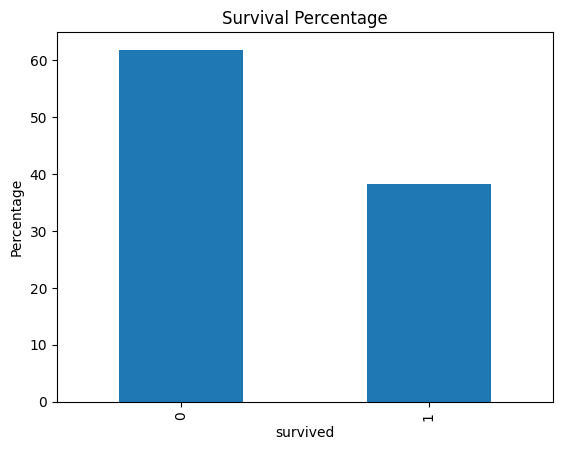

In [18]:
#Survival Rate
survival_rate= df['survived'].value_counts(normalize=True)*100
survival_rate.plot(kind='bar')
plt.title('Survival Percentage')
plt.ylabel('Percentage')
plt.show()

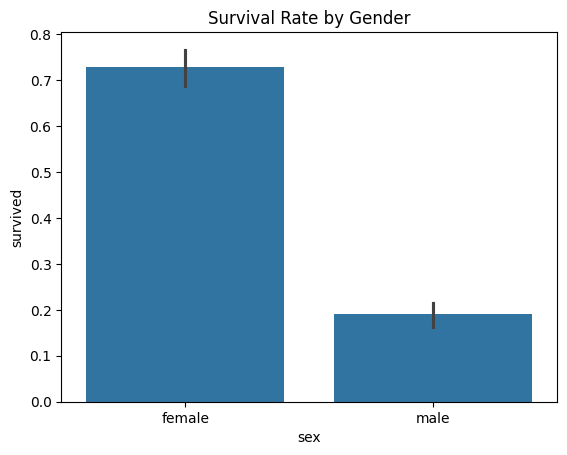

In [19]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

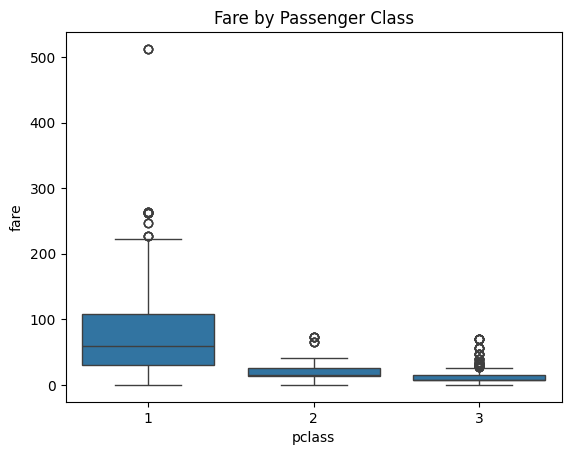

In [20]:
sns.boxplot(x='pclass', y='fare', data=df)
plt.title('Fare by Passenger Class')
plt.show()


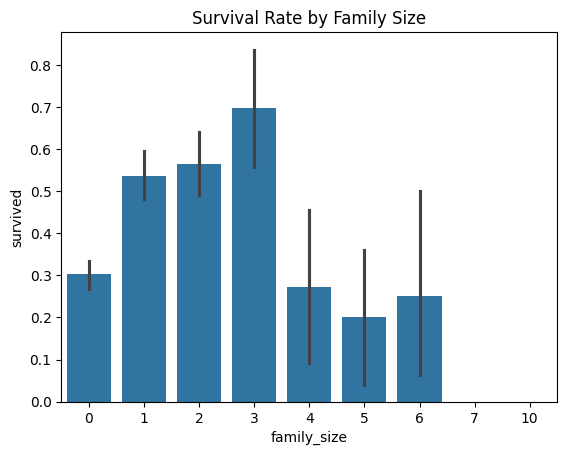

In [21]:
sns.barplot(x='family_size', y='survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

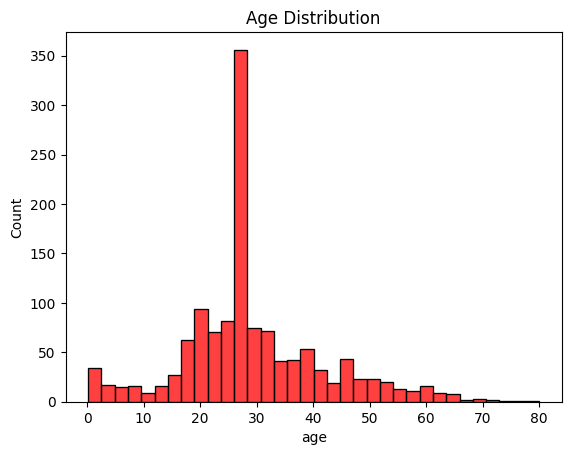

In [22]:
sns.histplot(df['age'], color='red')
plt.title('Age Distribution')
plt.show()

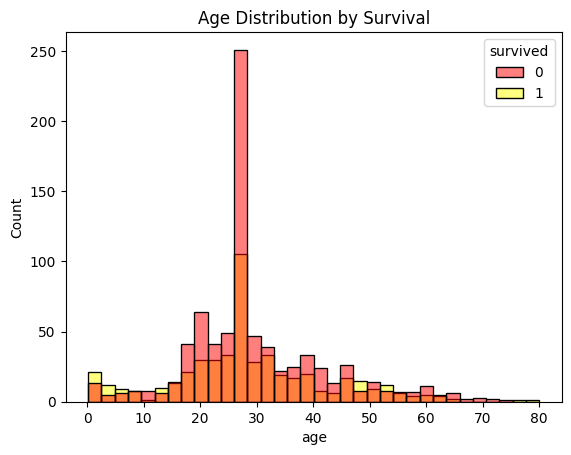

In [23]:
sns.histplot(data=df, x='age', hue='survived', palette=['red','yellow'] )
plt.title('Age Distribution by Survival')
plt.show()

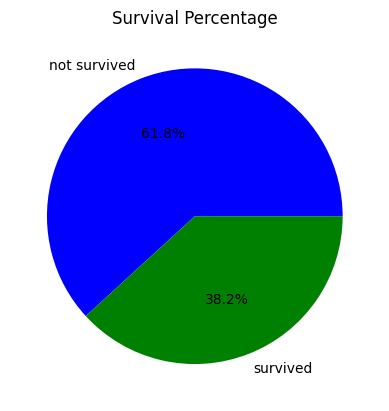

In [24]:
survival= df['survived'].value_counts()
plt.pie(survival, labels=['not survived', 'survived'], autopct='%1.1f%%', colors=['blue', 'green'])
plt.title('Survival Percentage')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pclass       1309 non-null   int64  
 1   survived     1309 non-null   int64  
 2   name         1309 non-null   object 
 3   sex          1309 non-null   object 
 4   age          1309 non-null   float64
 5   sibsp        1309 non-null   int64  
 6   parch        1309 non-null   int64  
 7   ticket       1309 non-null   object 
 8   fare         1309 non-null   float64
 9   cabin        1309 non-null   object 
 10  embarked     1309 non-null   object 
 11  boat         1309 non-null   object 
 12  body         1309 non-null   float64
 13  home.dest    1309 non-null   object 
 14  family_size  1309 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 153.5+ KB


In [27]:
df.drop(['name','ticket','home.dest','body','cabin','boat'],axis=1, inplace=True)

In [28]:
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,family_size
0,1,1,female,29.00,0,0,211.3375,S,0
1,1,1,male,0.92,1,2,151.5500,S,3
2,1,0,female,2.00,1,2,151.5500,S,3
3,1,0,male,30.00,1,2,151.5500,S,3
4,1,0,female,25.00,1,2,151.5500,S,3


In [29]:
df['sex']=df['sex'].map({'male':0, 'female':1})
df['embarked']=df['embarked'].map({'S':0, 'C':1, 'Q':2})

In [30]:
x=df.drop('survived', axis=1)
y=df['survived']

In [31]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [32]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred=model.predict(x_test)

In [34]:
print('Accuracy :', accuracy_score(y_test, y_pred))

Accuracy : 0.7824427480916031


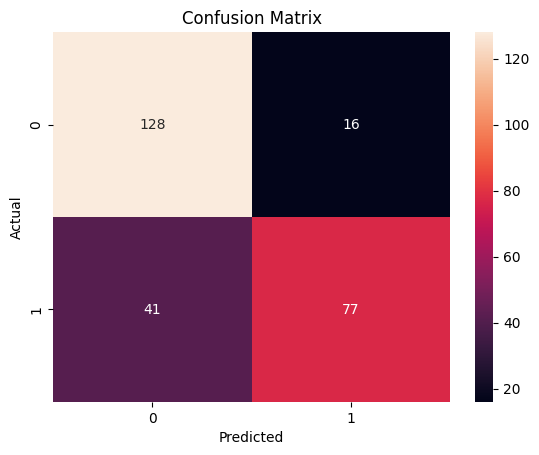

In [35]:
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()